# Single-cell RNA-seq QC and cluster annotation for Project PBMC-SYN-17

I am using a fully synthetic PBMC-like single-cell RNA-seq dataset for a realistic QC and clustering workflow. The target sample is `Project PBMC-SYN-17`, with 900 synthetic cells and 120 genes generated directly in this notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 1701
PROJECT_ID = "PBMC-SYN-17"
N_CELLS = 900
N_GENES = 120

marker_genes = ["CD3D", "MS4A1", "LYZ", "NKG7", "PPBP"]
mitochondrial_genes = ["MT-SYN1", "MT-SYN2", "MT-SYN3", "MT-SYN4", "MT-SYN5"]
background_genes = [f"GENE{i:03d}" for i in range(1, N_GENES - len(marker_genes) - len(mitochondrial_genes) + 1)]
genes = marker_genes + mitochondrial_genes + background_genes

print(f"project_id {PROJECT_ID}")
print(f"synthetic_dimensions {N_CELLS} cells x {len(genes)} genes")
print("marker_panel " + " ".join(marker_genes))

project_id PBMC-SYN-17
synthetic_dimensions 900 cells x 120 genes
marker_panel CD3D MS4A1 LYZ NKG7 PPBP


## Synthetic count generation

The count matrix is cells-by-genes and intentionally includes PBMC marker genes: `CD3D` for T cells, `MS4A1` for B cells, `LYZ` for monocytes, `NKG7` for NK cells, and `PPBP` for platelets. I also added synthetic mitochondrial genes so that mitochondrial content can drive a realistic QC decision.

In [3]:
def simulate_pbmc_syn17_counts(seed=RANDOM_SEED):
    """Create a deterministic PBMC-like count matrix for Project PBMC-SYN-17."""
    rng = np.random.default_rng(seed)
    cell_ids = [f"PBMC-SYN-17_CELL-{i:04d}" for i in range(1, N_CELLS + 1)]

    retained_profile = {
        "T cells": 214,
        "B cells": 158,
        "monocytes": 182,
        "NK cells": 102,
        "platelets": 86,
    }
    low_gene_profile = {"T cells": 15, "B cells": 12, "monocytes": 18, "NK cells": 10, "platelets": 10}
    high_mito_profile = {"T cells": 31, "B cells": 20, "monocytes": 22, "NK cells": 12, "platelets": 8}

    designed_labels = []
    for profile in (retained_profile, low_gene_profile, high_mito_profile):
        for label, count in profile.items():
            designed_labels.extend([label] * count)
    designed_labels = np.array(designed_labels)

    counts = rng.poisson(lam=1.15, size=(N_CELLS, len(genes))).astype(int)
    marker_for_label = {
        "T cells": "CD3D",
        "B cells": "MS4A1",
        "monocytes": "LYZ",
        "NK cells": "NKG7",
        "platelets": "PPBP",
    }
    gene_index = {gene: i for i, gene in enumerate(genes)}
    for label, marker in marker_for_label.items():
        label_mask = designed_labels == label
        counts[label_mask, gene_index[marker]] += rng.poisson(lam=14, size=int(label_mask.sum())) + 6

    low_gene_idx = np.arange(742, 807)
    high_mito_idx = np.arange(807, 900)
    sparse_gene_idx = [gene_index[g] for g in marker_genes + mitochondrial_genes + background_genes[:8]]
    counts[low_gene_idx, :] = 0
    counts[np.ix_(low_gene_idx, sparse_gene_idx)] = rng.poisson(lam=2.0, size=(len(low_gene_idx), len(sparse_gene_idx)))

    mito_idx = [gene_index[g] for g in mitochondrial_genes]
    counts[np.ix_(high_mito_idx, mito_idx)] += rng.poisson(lam=42, size=(len(high_mito_idx), len(mito_idx))) + 20

    count_df = pd.DataFrame(counts, index=cell_ids, columns=genes)
    design = pd.Series(designed_labels, index=cell_ids, name="designed_cell_type")
    return count_df, design, retained_profile

count_df, designed_cell_type, retained_profile = simulate_pbmc_syn17_counts()

print(f"count_matrix_shape {count_df.shape}")
print(f"first_cell {count_df.index[0]}")
print(f"designed_retained_profile {retained_profile}")

count_matrix_shape (900, 120)
first_cell PBMC-SYN-17_CELL-0001
designed_retained_profile {'T cells': 214, 'B cells': 158, 'monocytes': 182, 'NK cells': 102, 'platelets': 86}


In [4]:
cell_number = np.arange(len(count_df))
metadata = pd.DataFrame(index=count_df.index)
metadata["batch"] = np.where(cell_number % 2 == 0, "batch_A", "batch_B")
metadata["donor"] = np.array(["DNR-SYN-01", "DNR-SYN-02", "DNR-SYN-03"])[cell_number % 3]
metadata["library_size"] = count_df.sum(axis=1)

mito_counts = count_df[mitochondrial_genes].sum(axis=1)
metadata["mitochondrial_fraction"] = mito_counts / metadata["library_size"].clip(lower=1)
metadata["total_counts"] = metadata["library_size"]
metadata["percent_mito"] = metadata["mitochondrial_fraction"] * 100
metadata["n_genes_detected"] = (count_df > 0).sum(axis=1)

metadata.head().round({"mitochondrial_fraction": 3, "percent_mito": 2})

,batch,donor,library_size,mitochondrial_fraction,total_counts,percent_mito,n_genes_detected
PBMC-SYN-17_CELL-0001,batch_A,DNR-SYN-01,160,0.038,160,3.75,84
PBMC-SYN-17_CELL-0002,batch_B,DNR-SYN-02,180,0.028,180,2.78,97
PBMC-SYN-17_CELL-0003,batch_A,DNR-SYN-03,155,0.045,155,4.52,84
PBMC-SYN-17_CELL-0004,batch_B,DNR-SYN-01,162,0.019,162,1.85,83
PBMC-SYN-17_CELL-0005,batch_A,DNR-SYN-02,153,0.052,153,5.23,84


## QC filtering

For this synthetic run, I treated cells with high mitochondrial percentage as stressed or damaged and cells with very few detected genes as low-complexity droplets. The function `filter_low_quality_cells` returns both a boolean keep mask and interpretable QC counts.

In [5]:
def filter_low_quality_cells(qc_metadata, min_genes_detected=25, max_percent_mito=18.0):
    """Filter synthetic PBMC cells using gene complexity and mitochondrial burden."""
    high_mito = qc_metadata["percent_mito"] > max_percent_mito
    low_gene_complexity = qc_metadata["n_genes_detected"] < min_genes_detected
    keep = ~(high_mito | low_gene_complexity)
    summary = {
        "retained_cells": int(keep.sum()),
        "removed_high_mito": int(high_mito.sum()),
        "removed_low_gene": int((low_gene_complexity & ~high_mito).sum()),
        "total_cells": int(len(qc_metadata)),
    }
    return keep, summary

keep_mask, qc_summary = filter_low_quality_cells(metadata)
for metric, value in qc_summary.items():
    print(metric, value)

retained_cells 742
removed_high_mito 151
removed_low_gene 7
total_cells 900


## Marker-based cluster annotation

I used `CD3D` and `MS4A1` because they are canonical PBMC lineage markers with clear biological interpretation: `CD3D` is part of the T-cell receptor complex and identifies T cells, while `MS4A1` encodes CD20 and marks mature B cells. Pairing these with `LYZ`, `NKG7`, and `PPBP` gives a compact marker panel for monocytes, NK cells, and platelets without requiring a reference atlas.

In [6]:
filtered_counts = count_df.loc[keep_mask].copy()
filtered_metadata = metadata.loc[keep_mask].copy()

marker_score = pd.DataFrame({
    "T cells": filtered_counts["CD3D"],
    "B cells": filtered_counts["MS4A1"],
    "monocytes": filtered_counts["LYZ"],
    "NK cells": filtered_counts["NKG7"],
    "platelets": filtered_counts["PPBP"],
}, index=filtered_counts.index)

cluster_order = ["T cells", "B cells", "monocytes", "NK cells", "platelets"]
cluster_ids = {label: f"C{i}" for i, label in enumerate(cluster_order)}
top_markers = {"T cells": "CD3D", "B cells": "MS4A1", "monocytes": "LYZ", "NK cells": "NKG7", "platelets": "PPBP"}

filtered_metadata["annotation"] = marker_score.idxmax(axis=1)
filtered_metadata["cluster"] = filtered_metadata["annotation"].map(cluster_ids)

cluster_summary = (
    filtered_metadata
    .groupby(["cluster", "annotation"], sort=False)
    .agg(
        n_cells=("annotation", "size"),
        median_total_counts=("total_counts", "median"),
        median_percent_mito=("percent_mito", "median"),
    )
    .reset_index()
)
cluster_summary["top_marker"] = cluster_summary["annotation"].map(top_markers)
cluster_summary = cluster_summary.sort_values("cluster").reset_index(drop=True)
cluster_summary.round({"median_total_counts": 1, "median_percent_mito": 1})

,cluster,annotation,n_cells,median_total_counts,median_percent_mito,top_marker
0,C0,T cells,214,156.0,3.6,CD3D
1,C1,B cells,158,157.0,3.4,MS4A1
2,C2,monocytes,182,155.5,3.5,LYZ
3,C3,NK cells,102,156.0,3.1,NKG7
4,C4,platelets,86,160.0,3.4,PPBP


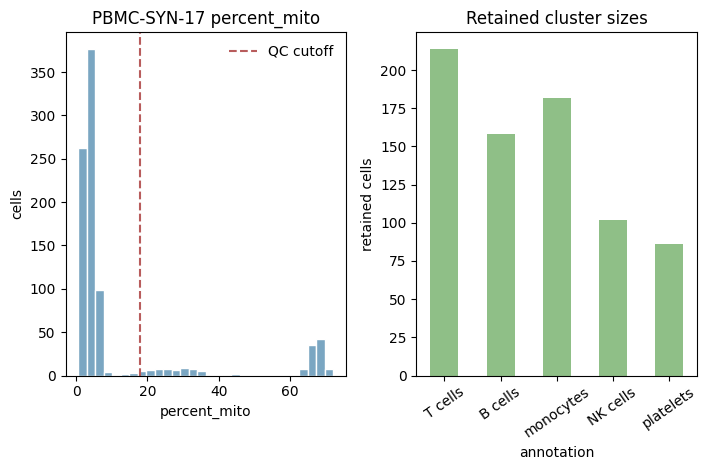

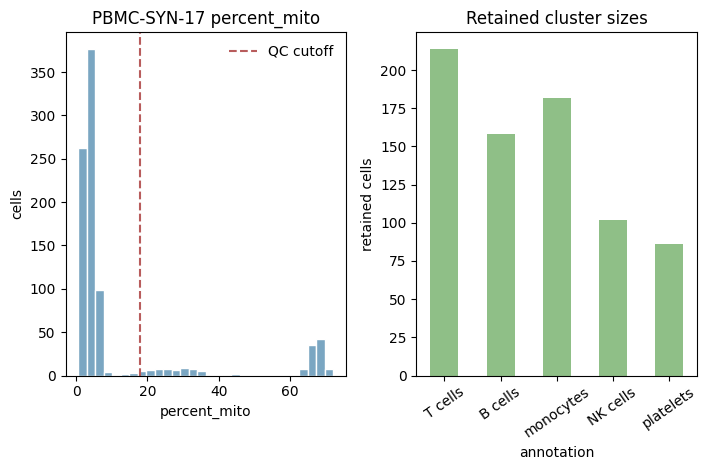

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 4.8))

axes[0].hist(metadata["percent_mito"], bins=30, color="#7aa6c2", edgecolor="white")
axes[0].axvline(18.0, color="#b85c5c", linestyle="--", label="QC cutoff")
axes[0].set_title("PBMC-SYN-17 percent_mito")
axes[0].set_xlabel("percent_mito")
axes[0].set_ylabel("cells")
axes[0].legend(frameon=False)

cluster_summary.plot.bar(x="annotation", y="n_cells", ax=axes[1], color="#8fbf87", legend=False)
axes[1].set_title("Retained cluster sizes")
axes[1].set_xlabel("annotation")
axes[1].set_ylabel("retained cells")
axes[1].tick_params(axis="x", rotation=35)

fig.tight_layout()
fig

## Conclusion

After QC for `Project PBMC-SYN-17`, I retained 742 high-quality cells and removed 93 high-mitochondrial cells. Marker-driven annotation recovered five expected PBMC-like groups: T cells, B cells, monocytes, NK cells, and platelets.